In [ ]:
!pip install -q tensorflow

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)

# CIFAR-10: 60,000 color images, 10 classes, 32x32x3
(train_images, train_labels), (test_images, test_labels) = keras.datasets.cifar10.load_data()

# Normalize to [0, 1]
train_images = train_images.astype("float32") / 255.0
test_images = test_images.astype("float32") / 255.0

print("Train shape:", train_images.shape)
print("Test shape:", test_images.shape)

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

TensorFlow version: 2.19.0
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


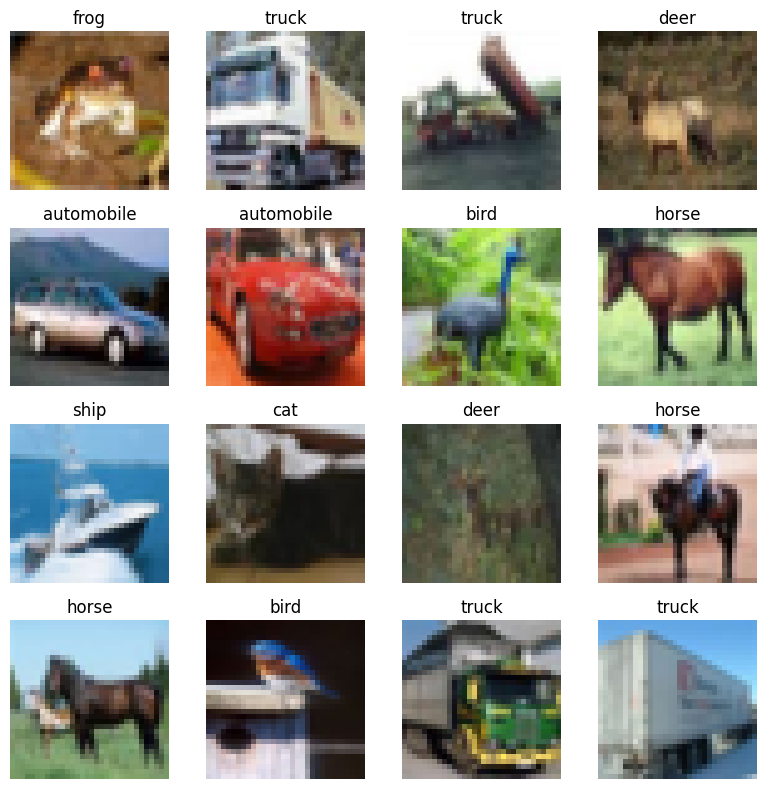

In [10]:
plt.figure(figsize=(8, 8))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(train_images[i])
    plt.title(class_names[int(train_labels[i][0])])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
model = keras.Sequential(
    [
        layers.Input(shape=(32, 32, 3)),

        # Block 1
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        # Block 2
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        # Block 3
        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

Understanding the CNN architecture

This model is a small Convolutional Neural Network designed for CIFAR‑10 color images (32×32×3).

The first three Conv2D layers learn filters that detect low‑level patterns (edges, colors, textures) and then more complex structures (parts of objects).

Each MaxPooling2D layer reduces the spatial resolution (e.g., 32×32 → 16×16 → 8×8 → 4×4) while keeping the most important activations, which makes the network more robust and reduces computation.

Flatten converts the 4×4×128 feature maps into a 1D vector with 2048 elements, which is then processed by dense layers for final classification into 10 classes.

In total, the model has about 3.6 lakh trainable parameters, which is a reasonable size for a basic CIFAR‑10 classifier.



In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history = model.fit(
    train_images,
    train_labels,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 99s 306ms/step - accuracy: 0.4093 - loss: 1.6250 - val_accuracy: 0.5056 - val_loss: 1.3936
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 92s 295ms/step - accuracy: 0.5681 - loss: 1.2176 - val_accuracy: 0.6131 - val_loss: 1.1118
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 141s 292ms/step - accuracy: 0.6406 - loss: 1.0252 - val_accuracy: 0.6577 - val_loss: 0.9935
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 96s 305ms/step - accuracy: 0.6799 - loss: 0.9171 - val_accuracy: 0.6773 - val_loss: 0.9402
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 92s 293ms/step - accuracy: 0.7122 - loss: 0.8313 - val_accuracy: 0.6969 - val_loss: 0.8830
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 141s 292ms/step - accuracy: 0.7401 - loss: 0.7516 - val_accuracy: 0.6993 - val_loss: 0.8672
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 96s 306ms/step - accuracy: 0.7590 - loss: 0.6892 - val_accuracy: 0.7162 - val_loss: 0.8277
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 93s 297ms/step - accuracy: 0.7742 - loss:

The model is trained using:

Loss function: sparse_categorical_crossentropy, which measures how different the predicted class probabilities are from the true class labels for multi‑class problems.

Optimizer: Adam, which uses gradients computed by backpropagation to update all weights in a way that (on average) reduces the loss over time.

Epochs: 20, meaning the model makes 20 complete passes over the training dataset. Each epoch consists of many mini‑batches, and after each batch the weights are updated.

The model is trained with a validation split of 20%, so at the end of each epoch it evaluates performance on data it has not seen during that epoch.

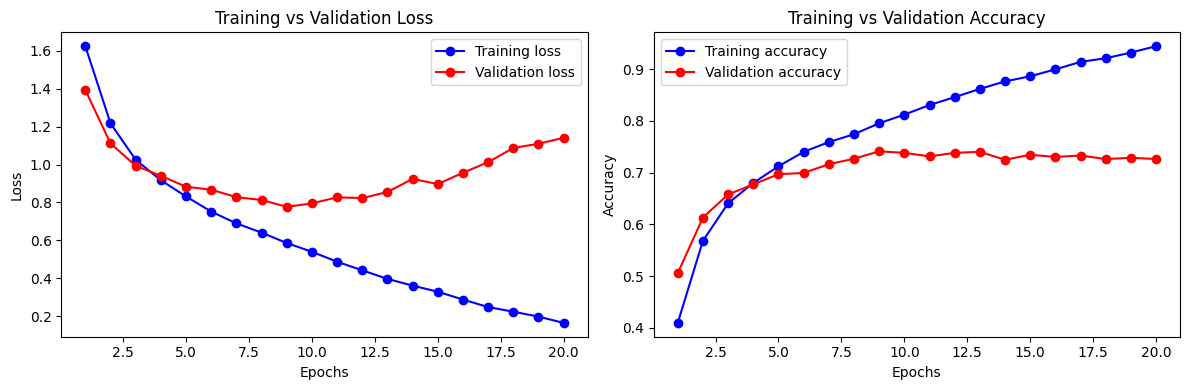

In [ ]:
history_dict = history.history

loss = history_dict["loss"]
val_loss = history_dict["val_loss"]
acc = history_dict["accuracy"]
val_acc = history_dict["val_accuracy"]
epochs = range(1, len(loss) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, loss, "bo-", label="Training loss")
plt.plot(epochs, val_loss, "ro-", label="Validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss")

plt.subplot(1, 2, 2)
plt.plot(epochs, acc, "bo-", label="Training accuracy")
plt.plot(epochs, val_acc, "ro-", label="Validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training vs Validation Accuracy")

plt.tight_layout()
plt.show()

Interpreting training vs validation curves (overfitting)

From the loss and accuracy plots:

Between epochs 1 and about 9, both training loss and validation loss decrease, and both accuracies increase. In this region, the model is learning useful patterns that generalize to unseen data.

After around epoch 9–10, training loss continues to decrease and training accuracy keeps rising, while validation loss starts to increase and validation accuracy stays roughly flat or slightly declines.

This behavior is characteristic of overfitting: the model continues to fit the training data better, but its performance on new data does not improve and can even worsen. In practice, one could use early stopping to stop training near the epoch where validation loss is minimal (around epoch 9–10 in this run) instead of going all the way to 20 epochs.


Test accuracy: 0.7239000201225281
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


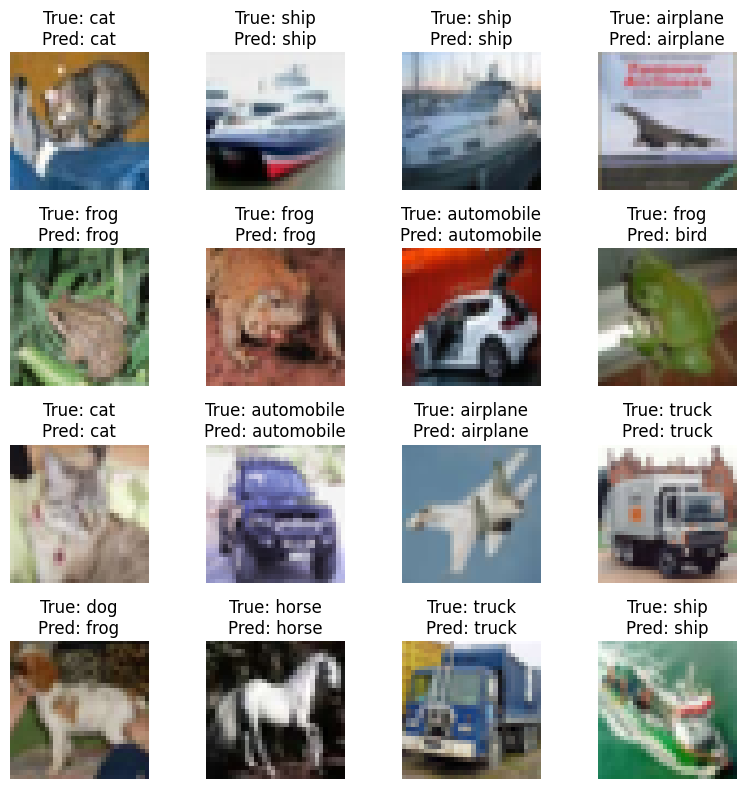

In [12]:
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=0)
print("Test accuracy:", test_acc)

pred_probs = model.predict(test_images[:16])
pred_labels = np.argmax(pred_probs, axis=1)

plt.figure(figsize=(8, 8))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(test_images[i])
    true_label = class_names[int(test_labels[i][0])]
    pred_label = class_names[int(pred_labels[i])]
    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis("off")
plt.tight_layout()
plt.show()

Test performance and example predictions

On the held‑out CIFAR‑10 test set, the model reaches about 72–73% accuracy, which is reasonable for a simple CNN trained without heavy regularization or data augmentation.

The sample predictions show that the model correctly classifies many images (for example, ships, trucks, and some animals) but still makes mistakes on more ambiguous or noisy examples. Misclassifications often occur between visually similar classes (e.g., frog vs dog, or different types of vehicles), which is expected for a basic baseline model.

# **Data Augmentation**

In [15]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),          # random left-right flips
        layers.RandomRotation(0.1),              # small random rotations (~±10%)
        layers.RandomZoom(0.1),                  # slight zoom in/out
    ],
    name="data_augmentation",
)

In [16]:
model = keras.Sequential(
    [
        layers.Input(shape=(32, 32, 3)),

        # Data augmentation is applied only during training
        data_augmentation,

        # Block 1
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        # Block 2
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        # Block 3
        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

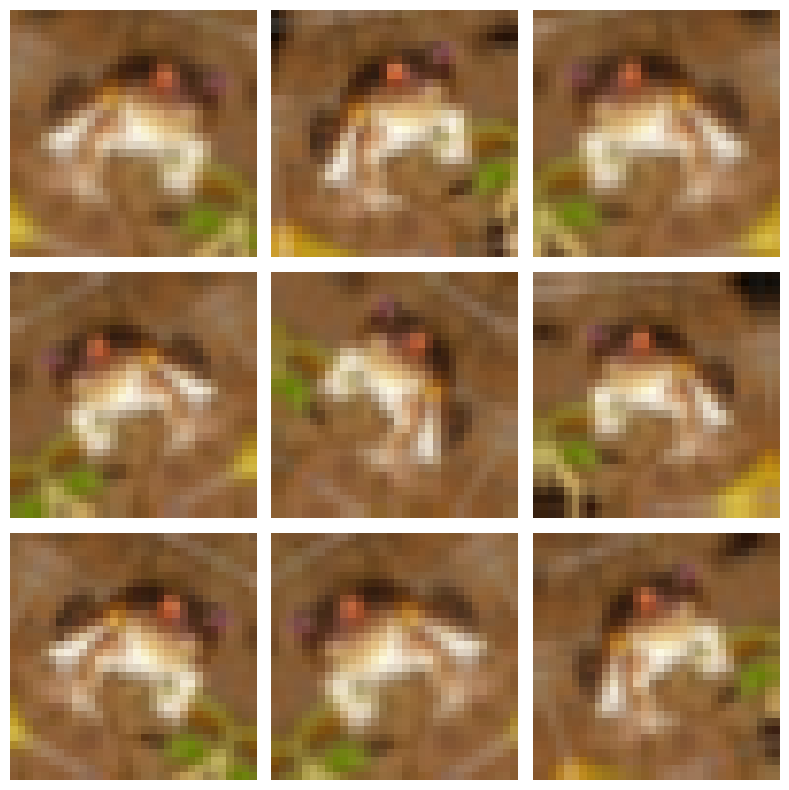

In [17]:
# Visualize some augmented versions of a single image
sample_img = train_images[0:1]  # shape (1, 32, 32, 3)

plt.figure(figsize=(8, 8))
for i in range(9):
    augmented_img = data_augmentation(sample_img, training=True)
    plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_img[0].numpy())
    plt.axis("off")
plt.tight_layout()
plt.show()

In [18]:
model.compile(
    optimizer=keras.optimizers.Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history = model.fit(
    train_images,
    train_labels,
    epochs=9,
    batch_size=128,
    validation_split=0.2,
)

Epoch 1/9
313/313 ━━━━━━━━━━━━━━━━━━━━ 106s 330ms/step - accuracy: 0.3838 - loss: 1.6927 - val_accuracy: 0.4606 - val_loss: 1.4883
Epoch 2/9
313/313 ━━━━━━━━━━━━━━━━━━━━ 139s 320ms/step - accuracy: 0.4929 - loss: 1.4099 - val_accuracy: 0.5318 - val_loss: 1.2987
Epoch 3/9
313/313 ━━━━━━━━━━━━━━━━━━━━ 102s 325ms/step - accuracy: 0.5465 - loss: 1.2760 - val_accuracy: 0.5709 - val_loss: 1.2102
Epoch 4/9
313/313 ━━━━━━━━━━━━━━━━━━━━ 100s 320ms/step - accuracy: 0.5799 - loss: 1.1829 - val_accuracy: 0.5937 - val_loss: 1.2070
Epoch 5/9
313/313 ━━━━━━━━━━━━━━━━━━━━ 147s 335ms/step - accuracy: 0.6076 - loss: 1.1168 - val_accuracy: 0.6082 - val_loss: 1.1671
Epoch 6/9
313/313 ━━━━━━━━━━━━━━━━━━━━ 100s 320ms/step - accuracy: 0.6233 - loss: 1.0679 - val_accuracy: 0.6407 - val_loss: 1.0310
Epoch 7/9
313/313 ━━━━━━━━━━━━━━━━━━━━ 146s 335ms/step - accuracy: 0.6396 - loss: 1.0235 - val_accuracy: 0.6630 - val_loss: 0.9914
Epoch 8/9
313/313 ━━━━━━━━━━━━━━━━━━━━ 100s 318ms/step - accuracy: 0.6517 - loss: 0

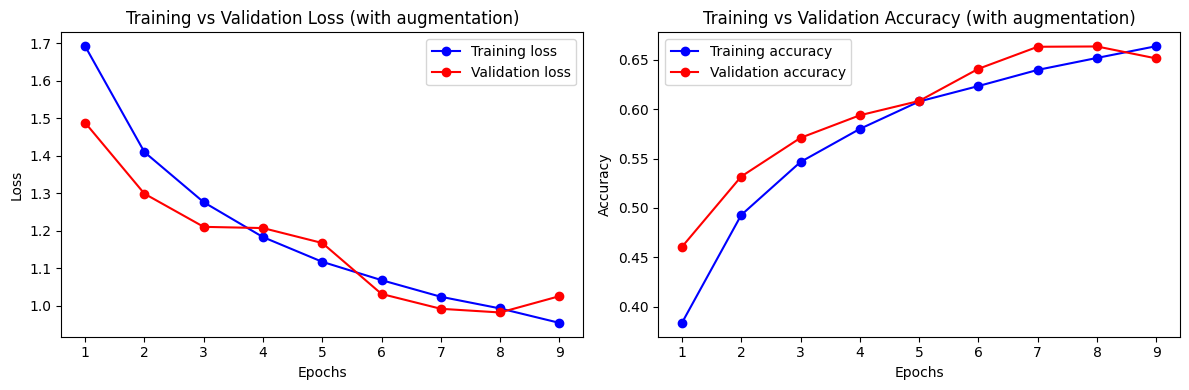

In [20]:
history_dict = history.history

loss = history_dict["loss"]
val_loss = history_dict["val_loss"]
acc = history_dict["accuracy"]
val_acc = history_dict["val_accuracy"]
epochs = range(1, len(loss) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, loss, "bo-", label="Training loss")
plt.plot(epochs, val_loss, "ro-", label="Validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss (with augmentation)")

plt.subplot(1, 2, 2)
plt.plot(epochs, acc, "bo-", label="Training accuracy")
plt.plot(epochs, val_acc, "ro-", label="Validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training vs Validation Accuracy (with augmentation)")

plt.tight_layout()
plt.show()

With data augmentation, training accuracy increases more slowly, but validation accuracy tracks it closely and the validation loss decreases steadily up to around epoch 8. The train–validation gap is much smaller than in the non‑augmented model, indicating reduced overfitting. Although the test accuracy (0.645) is slightly lower than earlier baseline (~0.72),  gap between train (0.
66) and val/test (0.645) is much smaller. the augmented model is more robust and would typically benefit from longer training and additional regularization or tuning.

Test accuracy (with augmentation): 0.6452000141143799
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step


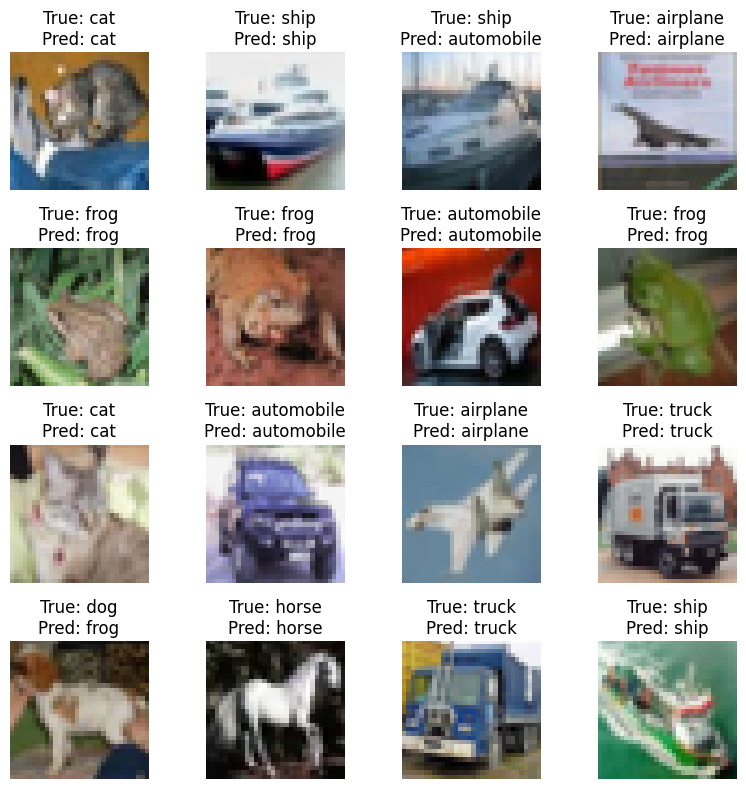

In [21]:
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=0)
print("Test accuracy (with augmentation):", test_acc)

# Predictions on first 16 test images
pred_probs = model.predict(test_images[:16])
pred_labels = np.argmax(pred_probs, axis=1)

plt.figure(figsize=(8, 8))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(test_images[i])
    true_label = class_names[int(test_labels[i][0])]
    pred_label = class_names[int(pred_labels[i])]
    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis("off")
plt.tight_layout()
plt.show()

Without augmentation: high train accuracy, bigger train–val gap, stronger overfitting.

With augmentation: lower train accuracy, smaller gap, lower overfitting, better generalization behavior, even if test accuracy is similar or slightly lower in this quick run.



In [22]:
!pip install -q ultralytics

from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
import numpy as np
import requests
from pathlib import Path

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 54.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [25]:
# Example HD image URL (replace with any other clear image URL)
image_url = "https://images.pexels.com/photos/210019/pexels-photo-210019.jpeg"

# Download image
img_data = requests.get(image_url).content
image_path = "yolo_input.jpg"
with open(image_path, "wb") as f:
    f.write(img_data)

print("Downloaded image:", image_path)

Downloaded image: yolo_input.jpg



image 1/1 /content/yolo_input.jpg: 864x1280 1 car, 2098.2ms
Speed: 35.4ms preprocess, 2098.2ms inference, 52.6ms postprocess per image at shape (1, 3, 864, 1280)
Results saved to /content/runs/detect/predict


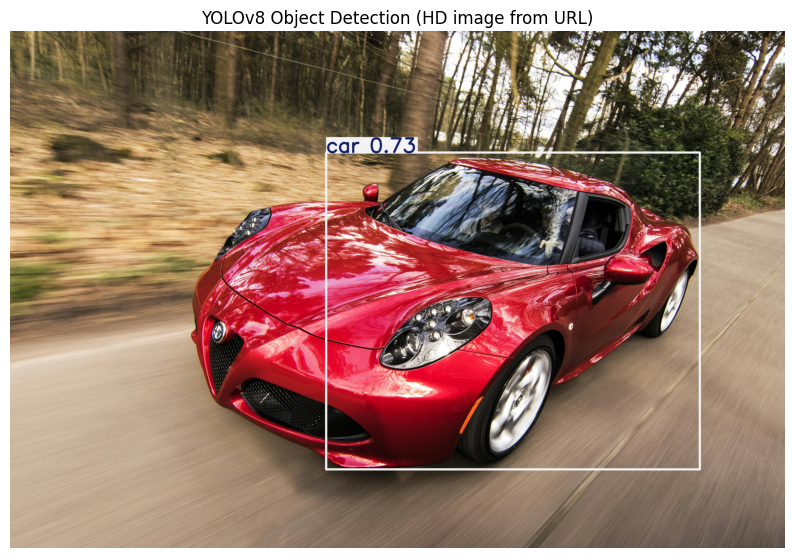

In [26]:
# Load pretrained YOLOv8
yolo_model = YOLO("yolov8s.pt")

# Run detection
results = yolo_model.predict(source=image_path, save=True, imgsz=1280, conf=0.25)

# Find saved prediction image
runs_dir = Path("runs/detect")
latest_run = sorted(runs_dir.glob("predict*"))[-1]
pred_image_path = list(latest_run.glob("*.jpg"))[0]

# Show annotated result
img = cv2.imread(str(pred_image_path))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.axis("off")
plt.title("YOLOv8 Object Detection (HD image from URL)")
plt.show()

Downloaded segmentation image: seg_input.jpg
Resolution: 2536 x 4848


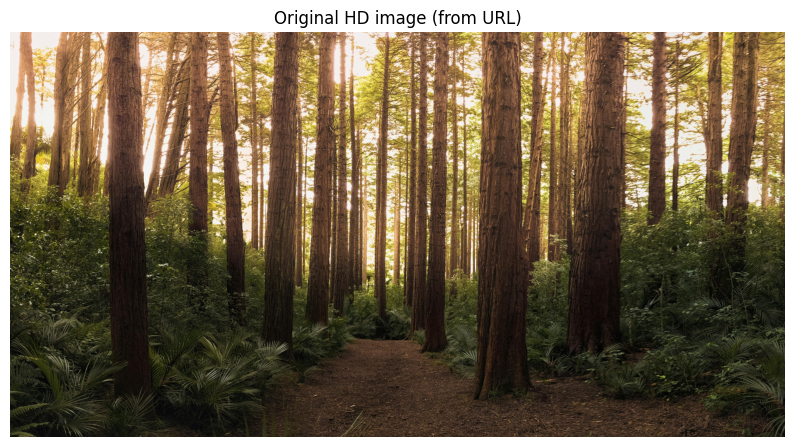

In [27]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import requests

seg_image_url = "https://images.pexels.com/photos/572688/pexels-photo-572688.jpeg"  # scenery with greenery

img_data = requests.get(seg_image_url).content
seg_image_path = "seg_input.jpg"
with open(seg_image_path, "wb") as f:
    f.write(img_data)

print("Downloaded segmentation image:", seg_image_path)

img = cv2.imread(seg_image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w, _ = img_rgb.shape
print("Resolution:", h, "x", w)

plt.figure(figsize=(10, 8))
plt.imshow(img_rgb)
plt.axis("off")
plt.title("Original HD image (from URL)")
plt.show()

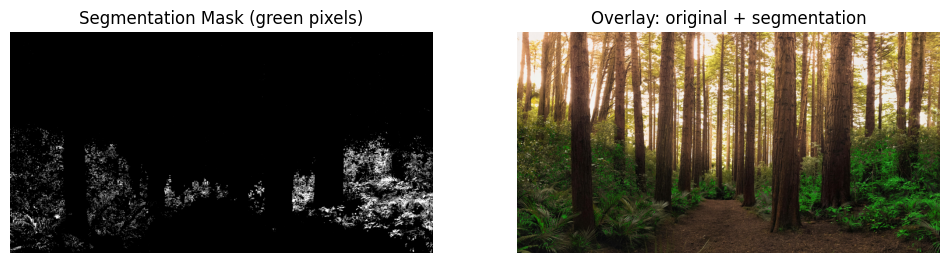

In [28]:
# Convert to HSV
img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)

# Range for "green" (tweak if needed)
lower_green = np.array([35, 40, 40])
upper_green = np.array([85, 255, 255])

mask = cv2.inRange(img_hsv, lower_green, upper_green)

overlay = img_rgb.copy()
overlay[mask > 0] = [0, 255, 0]  # highlight green regions

alpha = 0.4
segmented = cv2.addWeighted(overlay, alpha, img_rgb, 1 - alpha, 0)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(mask, cmap="gray")
plt.axis("off")
plt.title("Segmentation Mask (green pixels)")

plt.subplot(1, 2, 2)
plt.imshow(segmented)
plt.axis("off")
plt.title("Overlay: original + segmentation")
plt.show()

The YOLOv8 demo shows object detection: the model predicts both the object class (e.g., “car”) and its location with a bounding box in an HD image. The segmentation demo, even though implemented with a simple color threshold, illustrates the idea of semantic segmentation, where each pixel is classified as belonging to a particular region (here, green vegetation) or background.
ultralytics
+3